# Web analytics — market basket & customer segments

This notebook covers:

1. **Association rules** — FP-Growth *and* Apriori (same `min_support`), rule counts comparison, readable rules, and a **PDP-ready** table (antecedent size 1, `product_id`).
2. **Clustering** — K-Means with **elbow + silhouette**, justification for **k = 4**, **favorite_category** per cluster, **DBSCAN grid search** (exploratory) + **PCA** plot.

In [1]:
# --- paths: adjust if your CSVs are elsewhere ---
from pathlib import Path

DATA_DIR = Path("..") / "data" / "market_basket"
# DATA_DIR = Path(".")  # use if CSVs sit next to this notebook

ORDER_ITEMS = DATA_DIR / "order_items_dataset.csv"
CUSTOMERS = DATA_DIR / "customer_features_for_clustering.csv"
PRODUCTS = DATA_DIR / "products_catalog.csv"

for p in (ORDER_ITEMS, CUSTOMERS, PRODUCTS):
    if not p.exists():
        print(f"Missing file: {p.resolve()}")
    else:
        print("OK", p.name)

OK order_items_dataset.csv
OK customer_features_for_clustering.csv
OK products_catalog.csv


## Part 1 — Transactions (names for report, ids for website)

We build two parallel transaction lists from `order_items_dataset.csv`:

- **transactions**: product *names* (readable association rules).
- **transactions_ids**: `str(product_id)` items — same baskets, stable keys for Prisma / PDP.

In [2]:
import pandas as pd

orders = pd.read_csv(ORDER_ITEMS)
orders["product_id_str"] = orders["product_id"].astype(str)
print(orders.shape)
orders.head()

C:\Users\ilyes\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(5443, 12)


,order_id,customer_id,order_date,weekday,product_id,product_name,category,brand,unit_price,quantity,line_total,product_id_str
0,ORD_000001,CUST_0243,2026-04-02,4,321,SAUGE : Masque Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,28.26,1,28.26,321
1,ORD_000001,CUST_0243,2026-04-02,4,324,Crème Pieds Concentrée lissante,SOIN INTENSE (Mains & Pieds),Lirene,28.51,1,28.51,324
2,ORD_000001,CUST_0243,2026-04-02,4,320,MAGNOLIA : Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,22.09,1,22.09,320
3,ORD_000001,CUST_0243,2026-04-02,4,410,Shampoing Sebu-Balance,CAPILARTE,Dermedic,39.87,1,39.87,410
4,ORD_000002,CUST_0107,2025-07-25,5,392,Shampoing Anti-Chute Anti-Pelliculaire H-STIMU...,GAMME H - Cheveux et Cuir chevelu,Pharmaceris,42.50,1,42.50,392


In [3]:
orders = orders.dropna(subset=["order_id", "product_name"])

transactions = (
    orders.groupby("order_id")["product_name"]
    .apply(lambda items: sorted(set(items)))
    .tolist()
)

transactions_ids = (
    orders.groupby("order_id")["product_id_str"]
    .apply(lambda items: sorted(set(items)))
    .tolist()
)

id_to_name = (
    orders.drop_duplicates("product_id_str")[["product_id_str", "product_name"]]
    .set_index("product_id_str")["product_name"]
    .to_dict()
)

sizes = [len(t) for t in transactions]
print(f"Transactions: {len(transactions)}")
print(f"Basket size — min: {min(sizes)}, max: {max(sizes)}, avg: {sum(sizes)/len(sizes):.2f}")
print("Example (names):", transactions[0][:6])
print("Example (ids):", transactions_ids[0][:6])

Transactions: 1600
Basket size — min: 1, max: 8, avg: 3.40
Example (names): ['Crème Pieds Concentrée lissante', 'MAGNOLIA : Crème Mains et Ongles', 'SAUGE : Masque Crème Mains et Ongles', 'Shampoing Sebu-Balance']
Example (ids): ['320', '321', '324', '410']


## Part 1 — FP-Growth vs Apriori

Same `MIN_SUPPORT` → same **frequent itemsets** (FP-Growth and Apriori should agree). Then `association_rules` on those itemsets.

Rule filters for exploration: `confidence >= MIN_CONFIDENCE_RULES`, keep `lift > 1`.

In [4]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

MIN_SUPPORT = 0.01
MIN_CONFIDENCE_RULES = 0.2

te = TransactionEncoder()
df_bool = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=te.columns_,
)

itemsets_fp = fpgrowth(df_bool, min_support=MIN_SUPPORT, use_colnames=True)
itemsets_ap = apriori(df_bool, min_support=MIN_SUPPORT, use_colnames=True)

print("FP-Growth — frequent itemsets:", len(itemsets_fp))
print("Apriori  — frequent itemsets:", len(itemsets_ap))

# Same itemsets + support (within float tolerance)
fp_key = itemsets_fp.assign(
    _k=itemsets_fp["itemsets"].apply(lambda s: tuple(sorted(s)))
).sort_values("_k")
ap_key = itemsets_ap.assign(
    _k=itemsets_ap["itemsets"].apply(lambda s: tuple(sorted(s)))
).sort_values("_k")
merged = fp_key.merge(ap_key, on="_k", suffixes=("_fp", "_ap"))
max_diff = (merged["support_fp"] - merged["support_ap"]).abs().max()
print("Max |support_fp - support_ap|:", float(max_diff))

rules_fp = association_rules(
    itemsets_fp, metric="confidence", min_threshold=MIN_CONFIDENCE_RULES
)
rules_fp = rules_fp[rules_fp["lift"] > 1]

rules_ap_basis = association_rules(
    itemsets_ap, metric="confidence", min_threshold=MIN_CONFIDENCE_RULES
)
rules_ap_basis = rules_ap_basis[rules_ap_basis["lift"] > 1]

print("Rules (lift>1, conf threshold): from FP itemsets:", len(rules_fp))
print("Rules (lift>1, conf threshold): from Apriori itemsets:", len(rules_ap_basis))

itemsets_fp.sort_values("support", ascending=False).head(10)

FP-Growth — frequent itemsets: 147
Apriori  — frequent itemsets: 147
Max |support_fp - support_ap|: 0.0
Rules (lift>1, conf threshold): from FP itemsets: 139
Rules (lift>1, conf threshold): from Apriori itemsets: 139


,support,itemsets
37,0.063125,frozenset({Turbodraine ANANAS})
0,0.060000,frozenset({SAUGE : Masque Crème Mains et Ongles})
1,0.057500,frozenset({Crème Pieds Concentrée lissante})
5,0.056250,frozenset({Turbodraine AGRUMES})
20,0.053750,frozenset({XtraSlim Coupe-Faim})
27,0.053750,frozenset({XtraSlim Capteur 3 en 1})
23,0.051875,frozenset({Crème Hydratante SPF 15})
52,0.051875,frozenset({Brosse à dents électrique})
10,0.051250,frozenset({Turbodraine FRAMBOISE})
46,0.051250,frozenset({Crème Gel Ultra-hydratante})


In [5]:
cols = ["antecedents", "consequents", "support", "confidence", "lift"]
rules_fp.sort_values(["lift", "confidence"], ascending=False)[cols].head(15)

,antecedents,consequents,support,confidence,lift
117,frozenset({Gel Nettoyant Crèmeux}),frozenset({Sérum hydratant}),0.014375,0.315068,6.223575
116,frozenset({Sérum hydratant}),frozenset({Gel Nettoyant Crèmeux}),0.014375,0.283951,6.223575
81,frozenset({Mirawhite Shine}),frozenset({Kid’s Brush}),0.011875,0.292308,6.153846
82,frozenset({Kid’s Brush}),frozenset({Mirawhite Shine}),0.011875,0.250000,6.153846
4,frozenset({MAGNOLIA : Crème Mains et Ongles}),frozenset({CASSIS : Sérum Mains et Ongles}),0.015625,0.312500,6.097561
5,frozenset({CASSIS : Sérum Mains et Ongles}),frozenset({MAGNOLIA : Crème Mains et Ongles}),0.015625,0.304878,6.097561
46,frozenset({Shampoing Anti-Chute Anti-Cheveux G...,frozenset({Shampoing Cheveux Sec H-NUTRIMELIN ...,0.012500,0.256410,6.033183
45,frozenset({Shampoing Cheveux Sec H-NUTRIMELIN ...,frozenset({Shampoing Anti-Chute Anti-Cheveux G...,0.012500,0.294118,6.033183
87,frozenset({Eau micellaire démaquillante (visag...,frozenset({Gel Nettoyant Crèmeux}),0.012500,0.273973,6.004879
88,frozenset({Gel Nettoyant Crèmeux}),frozenset({Eau micellaire démaquillante (visag...,0.012500,0.273973,6.004879


### PDP-ready rules (website)

- Mine rules on **product-id** transactions.
- Keep **antecedent length == 1** (single product on PDP).
- Drop rules with **support < MIN_RULE_SUPPORT** (too niche).
- Table below: **top 10 by lift** after filters; includes `antecedent_product_id` for API/Prisma.

In [6]:
MIN_RULE_SUPPORT = 0.02

te_id = TransactionEncoder()
df_bool_id = pd.DataFrame(
    te_id.fit(transactions_ids).transform(transactions_ids),
    columns=te_id.columns_,
)

itemsets_id = fpgrowth(df_bool_id, min_support=MIN_SUPPORT, use_colnames=True)
rules_id = association_rules(
    itemsets_id, metric="confidence", min_threshold=MIN_CONFIDENCE_RULES
)
rules_id = rules_id[rules_id["lift"] > 1]

rules_id["ant_len"] = rules_id["antecedents"].apply(len)
pdp_rules = rules_id[
    (rules_id["ant_len"] == 1) & (rules_id["support"] >= MIN_RULE_SUPPORT)
].copy()
pdp_rules = pdp_rules.sort_values(["lift", "confidence"], ascending=False)


def froz_to_ids(fs):
    return [str(x) for x in sorted(fs)]


pdp_rules["antecedent_ids"] = pdp_rules["antecedents"].apply(froz_to_ids)
pdp_rules["consequent_ids"] = pdp_rules["consequents"].apply(froz_to_ids)
pdp_rules["antecedent_product_id"] = pdp_rules["antecedent_ids"].apply(lambda x: x[0])
pdp_rules["antecedent_name"] = pdp_rules["antecedent_product_id"].map(id_to_name)
pdp_rules["consequent_names"] = pdp_rules["consequent_ids"].apply(
    lambda xs: " | ".join(id_to_name.get(i, "?") for i in xs)
)

show_cols = [
    "antecedent_product_id",
    "antecedent_name",
    "consequent_ids",
    "consequent_names",
    "support",
    "confidence",
    "lift",
]
print(
    "PDP rules after filters:",
    len(pdp_rules),
    "(antecedent size 1, support >= %s)" % MIN_RULE_SUPPORT,
)
print("--- Top 10 by lift (also note minimum support threshold above) ---")
pdp_rules[show_cols].head(10)

PDP rules after filters: 0 (antecedent size 1, support >= 0.02)
--- Top 10 by lift (also note minimum support threshold above) ---


,antecedent_product_id,antecedent_name,consequent_ids,consequent_names,support,confidence,lift


## Part 2 — K-Means: elbow, silhouette, k = 4

Choose **k** using inertia (elbow) and mean silhouette; keep **k = 4** for the narrative if it sits near the silhouette peak or elbow bend — adjust `K_CHOSEN` if your metrics disagree.

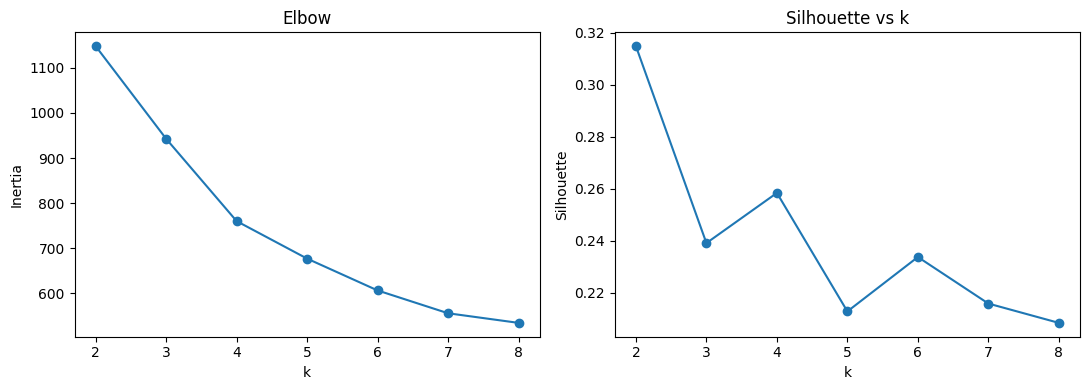

k	inertia	silhouette
2	1148	0.315  <- max silhouette
3	943	0.239
4	760	0.258
5	677	0.213
6	606	0.234
7	556	0.216
8	534	0.208

Using K_CHOSEN = 4 (compare to best silhouette k=2 when writing your justification).


In [7]:
cust = pd.read_csv(CUSTOMERS)
feature_cols = [
    "orders_count",
    "total_spend",
    "avg_order_value",
    "total_items",
    "avg_items_per_order",
    "distinct_products",
    "weekend_order_ratio",
]
X = cust[feature_cols].fillna(0)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Ks = range(2, 9)
inertias = []
silhouettes = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    lab = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lab))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(Ks), inertias, "o-")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow")

ax[1].plot(list(Ks), silhouettes, "o-")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette vs k")

plt.tight_layout()
plt.show()

best_k = list(Ks)[silhouettes.index(max(silhouettes))]
print("k\tinertia\tsilhouette")
for k, ine, sil in zip(Ks, inertias, silhouettes):
    tag = "  <- max silhouette" if k == best_k else ""
    print(f"{k}\t{ine:.0f}\t{sil:.3f}{tag}")

K_CHOSEN = 4
print(f"\nUsing K_CHOSEN = {K_CHOSEN} (compare to best silhouette k={best_k} when writing your justification).")

In [8]:
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init="auto")
cust["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

summary = cust.groupby("cluster_kmeans")[feature_cols].mean().round(2)
summary["favorite_category_mode"] = cust.groupby("cluster_kmeans")[
    "favorite_category"
].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else "—")
summary["n_customers"] = cust.groupby("cluster_kmeans").size()
summary

,orders_count,total_spend,avg_order_value,total_items,avg_items_per_order,distinct_products,weekend_order_ratio,favorite_category_mode,n_customers
cluster_kmeans,,,,,,,,,
0,6.90,1234.59,181.12,31.24,4.59,20.28,0.26,HYDRAIN,105
1,9.57,2200.30,233.70,52.74,5.58,31.00,0.28,Miradent,47
2,3.71,1177.94,321.91,26.54,7.21,16.04,0.33,Clinic Way,28
3,4.01,547.47,142.14,14.62,3.81,10.49,0.26,Miradent,80


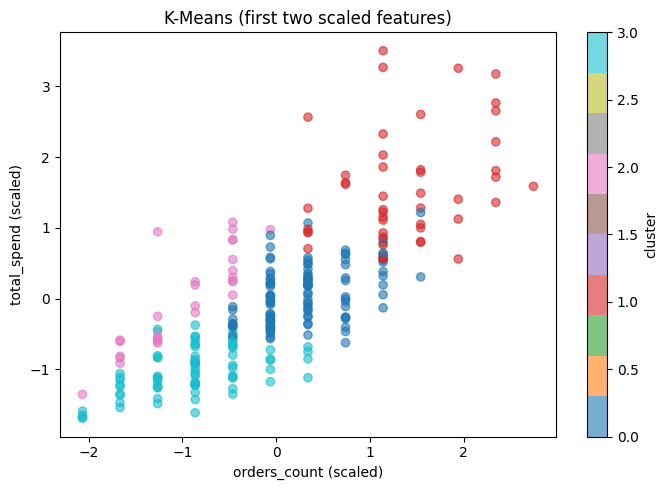

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cust["cluster_kmeans"],
    cmap="tab10",
    alpha=0.6,
)
plt.xlabel(feature_cols[0] + " (scaled)")
plt.ylabel(feature_cols[1] + " (scaled)")
plt.title("K-Means (first two scaled features)")
plt.colorbar(label="cluster")
plt.tight_layout()
plt.show()

## Part 2 — DBSCAN (exploratory)

Grid over **eps ∈ [1.0, 2.0]** and **min_samples ∈ {4,5,6}**. Pick a row with strong silhouette on non-noise points (and reasonable noise fraction). **PCA** scatter shows clusters + noise (-1).

Use DBSCAN as supplementary; **K-Means** stays the main segmentation story unless DBSCAN is clearly cleaner.

    eps  min_samples  n_noise  n_clusters_ex_noise  silhouette_non_noise
3   1.1            4       40                    2              0.457086
6   1.2            4       28                    3              0.232088
9   1.3            4       25                    3              0.230090
13  1.4            5       24                    2              0.221785
16  1.5            5       21                    3              0.204725
2   1.0            6       88                    2              0.187226
0   1.0            4       54                    5              0.110534
4   1.1            5       46                    4              0.044438
27  1.9            4        2                    1                   NaN
30  2.0            4        2                    1                   NaN
31  2.0            5        3                    1                   NaN
32  2.0            6        3                    1                   NaN
24  1.8            4        6                    1 

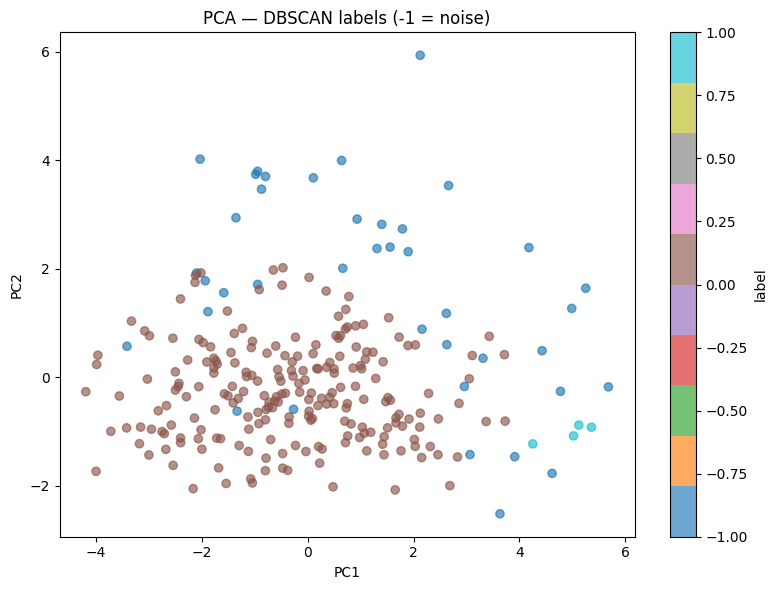

,orders_count,total_spend,avg_order_value,total_items,avg_items_per_order,distinct_products,weekend_order_ratio
cluster_dbscan,,,,,,,
-1,5.78,1598.44,291.31,36.40,6.58,20.75,0.41
0,6.12,1083.79,174.77,27.56,4.47,18.01,0.24
1,12.00,2947.43,245.62,66.00,5.50,38.50,0.42


In [10]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

eps_grid = np.linspace(1.0, 2.0, 11)
ms_grid = [4, 5, 6]

rows = []
for eps in eps_grid:
    for ms in ms_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(ms)).fit_predict(X_scaled)
        n_noise = int((db == -1).sum())
        mask = db != -1
        sil = np.nan
        if mask.sum() >= 2 and len(np.unique(db[mask])) >= 2:
            sil = silhouette_score(X_scaled[mask], db[mask])
        rows.append(
            {
                "eps": round(float(eps), 2),
                "min_samples": ms,
                "n_noise": n_noise,
                "n_clusters_ex_noise": len(set(db[mask])) if mask.any() else 0,
                "silhouette_non_noise": sil,
            }
        )

grid_df = pd.DataFrame(rows)
print(grid_df.sort_values(["silhouette_non_noise", "n_noise"], ascending=[False, True]).head(15))

valid = grid_df.dropna(subset=["silhouette_non_noise"])
if len(valid):
    best = valid.sort_values(
        ["silhouette_non_noise", "n_noise"], ascending=[False, True]
    ).iloc[0]
else:
    best = grid_df.sort_values("n_noise").iloc[0]

EPS_DB = float(best["eps"])
MS_DB = int(best["min_samples"])
print(f"\nSelected for PCA plot: eps={EPS_DB}, min_samples={MS_DB}")

cust["cluster_dbscan"] = DBSCAN(eps=EPS_DB, min_samples=MS_DB).fit_predict(X_scaled)
print(cust["cluster_dbscan"].value_counts())

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sc = plt.scatter(XY[:, 0], XY[:, 1], c=cust["cluster_dbscan"], cmap="tab10", alpha=0.65)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — DBSCAN labels (-1 = noise)")
plt.colorbar(sc, label="label")
plt.tight_layout()
plt.show()

cust.groupby("cluster_dbscan")[feature_cols].mean().round(2)

### Write-up

- Cite **FP vs Apriori** itemset counts and rule counts.
- PDP: **antecedent_product_id**, **support ≥ 0.02**, top 10 **lift**.
- K-Means: reference **elbow + silhouette** when defending **k = 4**; mention **favorite_category_mode**.
- DBSCAN: **exploratory**; interpret **-1** as noise.

**Packages:** `pip install pandas numpy mlxtend scikit-learn matplotlib`
